# Day 3 (Pandas)
---

## Some Basic Domain Knowledge

going to start by just gathering some domain knowledge since I know basically nothing about economics:

- **wth is gdp:** the total value of the products produced by your country (sold, exported, or just sitting in inventory) and the money made from services that your country has given.
- **gdp per capita:** its just the gdp divided by the total population, nothing complicated. Tells you the financial status of the average citizen of that country
- **CPI:** Consumer price index inflation, this is basically a fixed number of items that are purchased, the first year of purchase is called the base year purchase. so lets say the first year pakistan started calculating this was 2015, and in 2015 the total cost of all the items combined was lets say 10k. and now, the same exact group of items costs 11k. to find the CPI, all you gotta do is --> total price this year / total price on the base year * 100. so like 11k/10k * 100 and you have the CPI. So its kinds like accumulative inflation on the basic necessity items
- **Worker Remittence:** total money that people in pakistan receive from people abroad for personal use (like your son living in the US sending you a few thousand usd every month).
- **Goods and services exports**: GDP includes the goods in your inventory and all the stuff you solds to the locals, exports do not include either of those.
- **Foreign Direct Investment:** foreign company spending money to make something in your country, like china spending 100 bn usd to make some factories in pakistan.
- **Foreign Exchange Reserves:** the total amount of foreign cash that is left and sitting in the central bank.
- **Tax Revenue and GDP:** how big is the slice of the gdp that your gov collected from you.
- **Debt-to-GDP**: what percentage of the GDP is needed to pay all them debts.

## Brain storm some questions

1. is unemployment rate directly proportional to gdp? It should be a complete inverse relation (I think)
2. Does Pakistan do more imports than exports on average? Which year did it import the most and which year did it export the most?
3. has the gdp gone up as the population has increased?
4. when was/is pakistan most ready for digital banking? (when its has the most mobile subscriptions per 100 people)
5. When was accumulative inflation over general goods the lowest in pakistan (find the lowest CPI essentially)
6. Give a descending order chart or table showing what percentage of pakistan's gdp could have been used to pay the debts of the country.
7. Has the gdp gone up with the litracy rate? is it really a linear relation?
8. service sector vs industry sector vs agri sector, who owns the biggest slice of the GDP over the years?
9. did the litracy rate of the country go up when the country was on an IMF program? Did its GDP go up? did inflation go up?

---

## Loading the data

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("pakistan_economic_indicators_2000_2025.csv")
df.head()

,year,gdp_usd_bn,gdp_growth_pct,gdp_per_capita_usd,inflation_cpi_pct,unemployment_pct,remittances_usd_bn,exports_usd_bn,imports_usd_bn,trade_balance_usd_bn,...,mobile_per_100,imf_program_active,key_events,remittances_gdp_pct,exports_gdp_pct,imports_gdp_pct,fdi_gdp_pct,gdp_growth_category,inflation_category,decade
0,2000,99.9,3.9,624,4.4,7.8,1.08,9.2,10.3,-1.1,...,0.3,0,Post-sanctions recovery,1.08,9.21,10.31,0.31,Moderate Growth,Low,2000s
1,2001,101.4,2.0,614,3.1,7.8,1.46,9.8,10.3,-0.5,...,0.6,0,9/11 impact + debt relief,1.44,9.66,10.16,0.37,Low Growth,Low,2000s
2,2002,107.6,3.1,628,3.5,8.3,2.39,10.0,10.9,-0.9,...,1.8,0,Economic reform start,2.22,9.29,10.13,0.76,Moderate Growth,Low,2000s
3,2003,116.3,4.7,657,3.1,8.3,3.96,11.7,12.2,-0.5,...,3.3,0,Growth acceleration,3.40,10.06,10.49,0.46,Moderate Growth,Low,2000s
4,2004,126.7,7.4,697,7.4,7.7,3.87,14.0,15.5,-1.5,...,7.7,0,High growth period,3.05,11.05,12.23,0.88,High Growth,Moderate,2000s


## Some basic exploration

In [4]:
df.shape

(26, 32)

In [5]:
df.columns

Index(['year', 'gdp_usd_bn', 'gdp_growth_pct', 'gdp_per_capita_usd',
       'inflation_cpi_pct', 'unemployment_pct', 'remittances_usd_bn',
       'exports_usd_bn', 'imports_usd_bn', 'trade_balance_usd_bn',
       'forex_reserves_usd_bn', 'policy_rate_pct', 'pkr_per_usd',
       'public_debt_gdp_pct', 'current_account_usd_bn', 'fdi_inflows_usd_bn',
       'population_mn', 'literacy_rate_pct', 'agriculture_gdp_pct',
       'services_gdp_pct', 'industry_gdp_pct', 'tax_revenue_gdp_pct',
       'mobile_per_100', 'imf_program_active', 'key_events',
       'remittances_gdp_pct', 'exports_gdp_pct', 'imports_gdp_pct',
       'fdi_gdp_pct', 'gdp_growth_category', 'inflation_category', 'decade'],
      dtype='str')

In [6]:
# in loc, you put names of the columns and names of the rows, although  convieniently, the first column is always the index and hence you can just go 0 onwards simply
df.loc[25, : ]

year                                               2025
gdp_usd_bn                                        390.0
gdp_growth_pct                                      3.0
gdp_per_capita_usd                                 1390
inflation_cpi_pct                                   7.2
unemployment_pct                                    5.4
remittances_usd_bn                                 38.0
exports_usd_bn                                     34.0
imports_usd_bn                                     58.0
trade_balance_usd_bn                              -24.0
forex_reserves_usd_bn                              18.5
policy_rate_pct                                    11.0
pkr_per_usd                                       280.0
public_debt_gdp_pct                                65.0
current_account_usd_bn                              1.0
fdi_inflows_usd_bn                                  2.2
population_mn                                     241.5
literacy_rate_pct                               

In [7]:
# iloc is better I think, you can just use integers to get both rows and columns
df.iloc[0:10, 0:10]

,year,gdp_usd_bn,gdp_growth_pct,gdp_per_capita_usd,inflation_cpi_pct,unemployment_pct,remittances_usd_bn,exports_usd_bn,imports_usd_bn,trade_balance_usd_bn
0,2000,99.9,3.9,624,4.4,7.8,1.08,9.2,10.3,-1.1
1,2001,101.4,2.0,614,3.1,7.8,1.46,9.8,10.3,-0.5
2,2002,107.6,3.1,628,3.5,8.3,2.39,10.0,10.9,-0.9
3,2003,116.3,4.7,657,3.1,8.3,3.96,11.7,12.2,-0.5
4,2004,126.7,7.4,697,7.4,7.7,3.87,14.0,15.5,-1.5
5,2005,137.4,9.0,736,9.3,7.7,4.28,16.5,25.4,-8.9
6,2006,152.4,5.8,795,7.9,6.2,5.12,18.6,30.5,-11.9
7,2007,168.0,6.8,855,7.6,5.2,6.14,17.5,28.6,-11.1
8,2008,192.5,5.0,956,12.0,5.2,6.45,20.4,39.9,-19.5
9,2009,173.6,2.6,843,20.8,5.5,7.81,19.6,31.7,-12.1


In [8]:
# gotta do some filtreing and then that condition in the tasks. lets get the rows where the gdp_usd_bn is greater than 120
df[df["gdp_usd_bn"] > 120]

,year,gdp_usd_bn,gdp_growth_pct,gdp_per_capita_usd,inflation_cpi_pct,unemployment_pct,remittances_usd_bn,exports_usd_bn,imports_usd_bn,trade_balance_usd_bn,...,mobile_per_100,imf_program_active,key_events,remittances_gdp_pct,exports_gdp_pct,imports_gdp_pct,fdi_gdp_pct,gdp_growth_category,inflation_category,decade
4,2004,126.7,7.40,697,7.4,7.7,3.87,14.0,15.5,-1.5,...,7.7,0,High growth period,3.05,11.05,12.23,0.88,High Growth,Moderate,2000s
5,2005,137.4,9.00,736,9.3,7.7,4.28,16.5,25.4,-8.9,...,12.3,0,Record growth 8.6%,3.11,12.01,18.49,1.60,High Growth,Moderate,2000s
6,2006,152.4,5.80,795,7.9,6.2,5.12,18.6,30.5,-11.9,...,34.5,0,Growth slowdown,3.36,12.20,20.01,2.80,Moderate Growth,Moderate,2000s
7,2007,168.0,6.80,855,7.6,5.2,6.14,17.5,28.6,-11.1,...,55.1,1,Global commodity boom,3.65,10.42,17.02,3.33,High Growth,Moderate,2000s
8,2008,192.5,5.00,956,12.0,5.2,6.45,20.4,39.9,-19.5,...,58.3,0,Global financial crisis,3.35,10.60,20.73,2.83,Moderate Growth,High,2000s
9,2009,173.6,2.60,843,20.8,5.5,7.81,19.6,31.7,-12.1,...,57.7,1,IMF bailout + floods,4.50,11.29,18.26,1.35,Low Growth,Hyperinflationary,2000s
10,2010,177.1,1.60,843,11.7,5.6,8.91,19.3,34.7,-15.4,...,61.3,0,Floods recovery,5.03,10.90,19.59,1.14,Low Growth,High,2010s
11,2011,222.2,3.60,1043,13.7,6.0,11.20,24.8,43.6,-18.8,...,65.5,1,Debt restructuring,5.04,11.16,19.62,0.73,Moderate Growth,High,2010s
12,2012,239.6,4.40,1097,9.7,6.0,13.19,24.0,44.9,-20.9,...,72.6,1,IMF program + energy crisis,5.51,10.02,18.74,0.36,Moderate Growth,Moderate,2010s
13,2013,247.1,3.70,1109,7.4,6.2,13.92,24.7,45.1,-20.4,...,71.2,0,Political transition,5.63,10.00,18.25,0.54,Moderate Growth,Moderate,2010s


In [9]:
# how do you filter a row where both conditions are true? well, you use the bitwise &, why not AND, AND only works on an expression with single values (scalers). it doesn't work on rows of data like in python
# ok, get the rows where gdp is above 200 and imf loans are also being taken
df[(df["gdp_usd_bn"] > 200) & (df["imf_program_active"] == 1)]

,year,gdp_usd_bn,gdp_growth_pct,gdp_per_capita_usd,inflation_cpi_pct,unemployment_pct,remittances_usd_bn,exports_usd_bn,imports_usd_bn,trade_balance_usd_bn,...,mobile_per_100,imf_program_active,key_events,remittances_gdp_pct,exports_gdp_pct,imports_gdp_pct,fdi_gdp_pct,gdp_growth_category,inflation_category,decade
11,2011,222.2,3.60,1043,13.7,6.0,11.20,24.8,43.6,-18.8,...,65.5,1,Debt restructuring,5.04,11.16,19.62,0.73,Moderate Growth,High,2010s
12,2012,239.6,4.40,1097,9.7,6.0,13.19,24.0,44.9,-20.9,...,72.6,1,IMF program + energy crisis,5.51,10.02,18.74,0.36,Moderate Growth,Moderate,2010s
17,2017,305.0,5.20,1258,4.2,5.8,19.68,22.0,48.8,-26.8,...,72.1,1,CPEC investment peak,6.45,7.21,16.00,0.82,Moderate Growth,Low,2010s
18,2018,314.6,5.80,1268,5.1,5.8,21.02,24.8,60.9,-36.1,...,77.2,1,Twin deficits crisis,6.68,7.88,19.36,0.90,Moderate Growth,Moderate,2010s
20,2020,263.2,-0.50,1016,8.9,4.6,23.12,22.4,44.6,-22.2,...,80.0,1,COVID-19 pandemic,8.78,8.51,16.95,0.97,Recession/Negative,Moderate,2020s
21,2021,348.7,5.70,1315,8.9,6.3,31.10,31.8,72.7,-40.9,...,82.4,1,Post-COVID rebound,8.92,9.12,20.85,0.52,Moderate Growth,Moderate,2020s
23,2023,337.9,-0.04,1237,29.2,6.5,26.10,27.7,55.3,-27.6,...,84.0,1,IMF bailout + PKR crash,7.72,8.20,16.37,0.44,Recession/Negative,Hyperinflationary,2020s
24,2024,374.6,2.40,1353,23.4,6.4,34.60,31.0,53.2,-22.2,...,85.5,1,Stabilization + disinflation,9.24,8.28,14.20,0.51,Low Growth,Hyperinflationary,2020s
25,2025,390.0,3.00,1390,7.2,5.4,38.00,34.0,58.0,-24.0,...,87.0,1,Recovery + record remittances,9.74,8.72,14.87,0.56,Low Growth,Moderate,2020s


In [10]:
df.groupby("gdp_usd_bn")["imf_program_active"]

it just returns a groupby object, its doing lazy evaluation, basically the same concept as a django queryset (building an sql query as you until some trigger is hit)

In [11]:
# the column you gruop by becomes the index of the new df you get, the column you perform the aggergation command on becomes the next column in the new df
df.groupby("gdp_usd_bn")["literacy_rate_pct"].mean()

gdp_usd_bn
99.9     43.9
101.4    45.0
107.6    46.0
116.3    47.0
126.7    48.7
137.4    50.5
152.4    52.0
168.0    53.6
173.6    55.5
177.1    57.7
192.5    54.2
222.2    58.1
239.6    58.9
247.1    60.1
263.2    58.0
263.7    62.8
270.6    60.9
271.1    58.0
282.5    59.4
305.0    60.0
314.6    62.3
337.9    62.3
348.7    59.1
374.6    63.0
376.5    60.1
390.0    64.0
Name: literacy_rate_pct, dtype: float64

In [12]:
# and you can groupby multiple columns too, so in the following, for every gdp, and then gor every possible imf_program_active value in that gdp, we get the mean of literacy rate
df.groupby(['gdp_usd_bn', 'imf_program_active'])['literacy_rate_pct'].mean()


gdp_usd_bn  imf_program_active
99.9        0                     43.9
101.4       0                     45.0
107.6       0                     46.0
116.3       0                     47.0
126.7       0                     48.7
137.4       0                     50.5
152.4       0                     52.0
168.0       1                     53.6
173.6       1                     55.5
177.1       0                     57.7
192.5       0                     54.2
222.2       1                     58.1
239.6       1                     58.9
247.1       0                     60.1
263.2       1                     58.0
263.7       0                     62.8
270.6       0                     60.9
271.1       0                     58.0
282.5       0                     59.4
305.0       1                     60.0
314.6       1                     62.3
337.9       1                     62.3
348.7       1                     59.1
374.6       1                     63.0
376.5       0                    

In [13]:
# what if i want mean of two columns? well just make the right side an array and add both
df.groupby('gdp_usd_bn')[['literacy_rate_pct', 'inflation_cpi_pct']].mean()

,literacy_rate_pct,inflation_cpi_pct
gdp_usd_bn,,
99.9,43.9,4.4
101.4,45.0,3.1
107.6,46.0,3.5
116.3,47.0,3.1
126.7,48.7,7.4
137.4,50.5,9.3
152.4,52.0,7.9
168.0,53.6,7.6
173.6,55.5,20.8


In [14]:
# print if any cell is empty (you will see true in that cell)
df.isna()

,year,gdp_usd_bn,gdp_growth_pct,gdp_per_capita_usd,inflation_cpi_pct,unemployment_pct,remittances_usd_bn,exports_usd_bn,imports_usd_bn,trade_balance_usd_bn,...,mobile_per_100,imf_program_active,key_events,remittances_gdp_pct,exports_gdp_pct,imports_gdp_pct,fdi_gdp_pct,gdp_growth_category,inflation_category,decade
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [15]:
# print how many empty cells you got for each column
df.isna().sum()

year                      0
gdp_usd_bn                0
gdp_growth_pct            0
gdp_per_capita_usd        0
inflation_cpi_pct         0
unemployment_pct          0
remittances_usd_bn        0
exports_usd_bn            0
imports_usd_bn            0
trade_balance_usd_bn      0
forex_reserves_usd_bn     0
policy_rate_pct           0
pkr_per_usd               0
public_debt_gdp_pct       0
current_account_usd_bn    0
fdi_inflows_usd_bn        0
population_mn             0
literacy_rate_pct         0
agriculture_gdp_pct       0
services_gdp_pct          0
industry_gdp_pct          0
tax_revenue_gdp_pct       0
mobile_per_100            0
imf_program_active        0
key_events                0
remittances_gdp_pct       0
exports_gdp_pct           0
imports_gdp_pct           0
fdi_gdp_pct               0
gdp_growth_category       0
inflation_category        0
decade                    0
dtype: int64

In [16]:
# diff between df2 = df and df2 = df.copy() is just that the former does shallow copy and the latter does deep copy
df2 = df.copy()
df2.head()

,year,gdp_usd_bn,gdp_growth_pct,gdp_per_capita_usd,inflation_cpi_pct,unemployment_pct,remittances_usd_bn,exports_usd_bn,imports_usd_bn,trade_balance_usd_bn,...,mobile_per_100,imf_program_active,key_events,remittances_gdp_pct,exports_gdp_pct,imports_gdp_pct,fdi_gdp_pct,gdp_growth_category,inflation_category,decade
0,2000,99.9,3.9,624,4.4,7.8,1.08,9.2,10.3,-1.1,...,0.3,0,Post-sanctions recovery,1.08,9.21,10.31,0.31,Moderate Growth,Low,2000s
1,2001,101.4,2.0,614,3.1,7.8,1.46,9.8,10.3,-0.5,...,0.6,0,9/11 impact + debt relief,1.44,9.66,10.16,0.37,Low Growth,Low,2000s
2,2002,107.6,3.1,628,3.5,8.3,2.39,10.0,10.9,-0.9,...,1.8,0,Economic reform start,2.22,9.29,10.13,0.76,Moderate Growth,Low,2000s
3,2003,116.3,4.7,657,3.1,8.3,3.96,11.7,12.2,-0.5,...,3.3,0,Growth acceleration,3.40,10.06,10.49,0.46,Moderate Growth,Low,2000s
4,2004,126.7,7.4,697,7.4,7.7,3.87,14.0,15.5,-1.5,...,7.7,0,High growth period,3.05,11.05,12.23,0.88,High Growth,Moderate,2000s


In [17]:
df2.iloc[0, 0] = 1999
df2.head()

,year,gdp_usd_bn,gdp_growth_pct,gdp_per_capita_usd,inflation_cpi_pct,unemployment_pct,remittances_usd_bn,exports_usd_bn,imports_usd_bn,trade_balance_usd_bn,...,mobile_per_100,imf_program_active,key_events,remittances_gdp_pct,exports_gdp_pct,imports_gdp_pct,fdi_gdp_pct,gdp_growth_category,inflation_category,decade
0,1999,99.9,3.9,624,4.4,7.8,1.08,9.2,10.3,-1.1,...,0.3,0,Post-sanctions recovery,1.08,9.21,10.31,0.31,Moderate Growth,Low,2000s
1,2001,101.4,2.0,614,3.1,7.8,1.46,9.8,10.3,-0.5,...,0.6,0,9/11 impact + debt relief,1.44,9.66,10.16,0.37,Low Growth,Low,2000s
2,2002,107.6,3.1,628,3.5,8.3,2.39,10.0,10.9,-0.9,...,1.8,0,Economic reform start,2.22,9.29,10.13,0.76,Moderate Growth,Low,2000s
3,2003,116.3,4.7,657,3.1,8.3,3.96,11.7,12.2,-0.5,...,3.3,0,Growth acceleration,3.40,10.06,10.49,0.46,Moderate Growth,Low,2000s
4,2004,126.7,7.4,697,7.4,7.7,3.87,14.0,15.5,-1.5,...,7.7,0,High growth period,3.05,11.05,12.23,0.88,High Growth,Moderate,2000s


In [18]:
df.head()

,year,gdp_usd_bn,gdp_growth_pct,gdp_per_capita_usd,inflation_cpi_pct,unemployment_pct,remittances_usd_bn,exports_usd_bn,imports_usd_bn,trade_balance_usd_bn,...,mobile_per_100,imf_program_active,key_events,remittances_gdp_pct,exports_gdp_pct,imports_gdp_pct,fdi_gdp_pct,gdp_growth_category,inflation_category,decade
0,2000,99.9,3.9,624,4.4,7.8,1.08,9.2,10.3,-1.1,...,0.3,0,Post-sanctions recovery,1.08,9.21,10.31,0.31,Moderate Growth,Low,2000s
1,2001,101.4,2.0,614,3.1,7.8,1.46,9.8,10.3,-0.5,...,0.6,0,9/11 impact + debt relief,1.44,9.66,10.16,0.37,Low Growth,Low,2000s
2,2002,107.6,3.1,628,3.5,8.3,2.39,10.0,10.9,-0.9,...,1.8,0,Economic reform start,2.22,9.29,10.13,0.76,Moderate Growth,Low,2000s
3,2003,116.3,4.7,657,3.1,8.3,3.96,11.7,12.2,-0.5,...,3.3,0,Growth acceleration,3.40,10.06,10.49,0.46,Moderate Growth,Low,2000s
4,2004,126.7,7.4,697,7.4,7.7,3.87,14.0,15.5,-1.5,...,7.7,0,High growth period,3.05,11.05,12.23,0.88,High Growth,Moderate,2000s


In [19]:
# the original didn't change, that is deep copy essentially

## The task

### The question (going with the same ones I brain stormed initially)
1. is unemployment rate directly proportional to gdp? It should be a complete inverse relation (I think)
2. Does Pakistan do more imports than exports on average? Which year did it import the most and which year did it export the most?
3. has the gdp gone up as the population has increased?
4. when was/is pakistan most ready for digital banking? (when its has the most mobile subscriptions per 100 people)
5. When was accumulative inflation over general goods the lowest in pakistan (find the lowest CPI essentially)
6. Give a descending order chart or table showing what percentage of pakistan's gdp could have been used to pay the debts of the country.
7. Has the gdp gone up with the litracy rate? is it really a linear relation?
8. service sector vs industry sector vs agri sector, who owns the biggest slice of the GDP over the years?
9. did the litracy rate of the country go up when the country was on an IMF program? Did its GDP go up? did inflation go up?


### 1: is unemployment rate directly proportional to gdp? It should be a complete inverse relation (I think)

In [20]:
# for an inverse relation, all we need to see is if the correlation between the 2 columns is close to -1 or exactly -1 or not
df["gdp_usd_bn"].corr(df["unemployment_pct"])

np.float64(-0.5334804114594857)

- well, not a perfect -1 but it is an inverse relation. When gdp goes down, companies don't just fire everyone on day 1, it takes time. so this makes sense I guess

### 2. Does Pakistan do more imports than exports on average? Which year did it import the most and which year did it export the most?


In [21]:
df.groupby("year")[["imports_usd_bn", "exports_usd_bn"]].mean()

,imports_usd_bn,exports_usd_bn
year,,
2000,10.3,9.2
2001,10.3,9.8
2002,10.9,10.0
2003,12.2,11.7
2004,15.5,14.0
2005,25.4,16.5
2006,30.5,18.6
2007,28.6,17.5
2008,39.9,20.4


In [22]:
print(f"Averge imports from 2000 to 2025: {df["imports_usd_bn"].mean():.2f}")
print(f"Averge exports from 2000 to 2025: {df["exports_usd_bn"].mean():.2f}")

Averge imports from 2000 to 2025: 39.85
Averge exports from 2000 to 2025: 21.45


- well, looks like we import a lot more than we export, thats pretty sad

In [23]:
df["exports_usd_bn"].idxmax()

25

In [24]:
df.iloc[25]

year                                               2025
gdp_usd_bn                                        390.0
gdp_growth_pct                                      3.0
gdp_per_capita_usd                                 1390
inflation_cpi_pct                                   7.2
unemployment_pct                                    5.4
remittances_usd_bn                                 38.0
exports_usd_bn                                     34.0
imports_usd_bn                                     58.0
trade_balance_usd_bn                              -24.0
forex_reserves_usd_bn                              18.5
policy_rate_pct                                    11.0
pkr_per_usd                                       280.0
public_debt_gdp_pct                                65.0
current_account_usd_bn                              1.0
fdi_inflows_usd_bn                                  2.2
population_mn                                     241.5
literacy_rate_pct                               

In [25]:
df.iloc[df["imports_usd_bn"].idxmax(), :]

year                                           2022
gdp_usd_bn                                    376.5
gdp_growth_pct                                  6.1
gdp_per_capita_usd                             1393
inflation_cpi_pct                              12.2
unemployment_pct                                6.2
remittances_usd_bn                            27.02
exports_usd_bn                                 32.4
imports_usd_bn                                 80.0
trade_balance_usd_bn                          -47.6
forex_reserves_usd_bn                          13.7
policy_rate_pct                                16.0
pkr_per_usd                                   204.9
public_debt_gdp_pct                            73.0
current_account_usd_bn                        -17.5
fdi_inflows_usd_bn                             1.93
population_mn                                 228.5
literacy_rate_pct                              60.1
agriculture_gdp_pct                            23.4
services_gdp

- 80 billion USD in imports in 2022 is the max for imports
- 34 billion USD in exports in 2025 is the max for exports

### 3. has the gdp gone up as the population has increased?


In [26]:
df["gdp_usd_bn"].corr(df["population_mn"])

np.float64(0.9744300748467151)

- yes, there is a very high and hence gdp definitely goes up as population goes up. Lets draw a simple line chart, the line should be roughy linear

<Axes: title={'center': 'Line Chat of GDP VS Population'}, xlabel='gdp_usd_bn'>

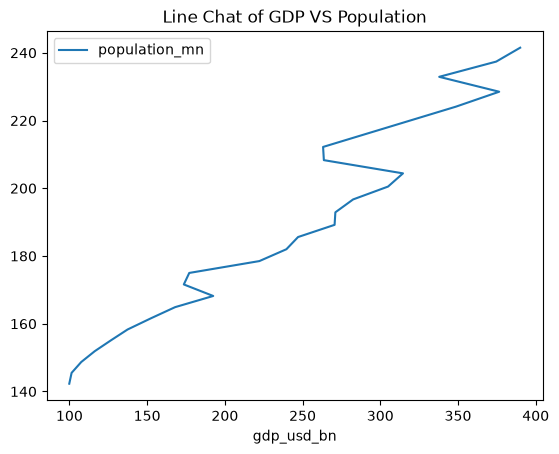

In [27]:
df.plot(x="gdp_usd_bn", y="population_mn", title="Line Chat of GDP VS Population")

### 4. when was/is pakistan most ready for digital banking? (when its has the most mobile subscriptions per 100 people)

In [28]:
df.loc[df["mobile_per_100"].idxmax()]

year                                               2025
gdp_usd_bn                                        390.0
gdp_growth_pct                                      3.0
gdp_per_capita_usd                                 1390
inflation_cpi_pct                                   7.2
unemployment_pct                                    5.4
remittances_usd_bn                                 38.0
exports_usd_bn                                     34.0
imports_usd_bn                                     58.0
trade_balance_usd_bn                              -24.0
forex_reserves_usd_bn                              18.5
policy_rate_pct                                    11.0
pkr_per_usd                                       280.0
public_debt_gdp_pct                                65.0
current_account_usd_bn                              1.0
fdi_inflows_usd_bn                                  2.2
population_mn                                     241.5
literacy_rate_pct                               

- so in 2025, we had the most phone subscriptions, and hence that would be the best year for digital banking etc. Lets print both columns

In [29]:
df[["year", "mobile_per_100"]]

,year,mobile_per_100
0,2000,0.3
1,2001,0.6
2,2002,1.8
3,2003,3.3
4,2004,7.7
5,2005,12.3
6,2006,34.5
7,2007,55.1
8,2008,58.3
9,2009,57.7


### 5. When was accumulative inflation over general goods the lowest in pakistan (find the lowest CPI essentially)

In [30]:
print(f"Inflatioon CPI was the highes in the year: {df.loc[df["inflation_cpi_pct"].idxmin()].iloc[0]}")
# sidenot: that df.loc[df["inflation_cpi_pct"].idxmin()] actually returns a series, and you can just throw an iloc on the series to get an item from it by index

Inflatioon CPI was the highes in the year: 2016


### 6. Give a descending order table showing what percentage of pakistan's gdp was public debt and turn it into the corresponding number instead of percentage.


In [31]:
df.columns

Index(['year', 'gdp_usd_bn', 'gdp_growth_pct', 'gdp_per_capita_usd',
       'inflation_cpi_pct', 'unemployment_pct', 'remittances_usd_bn',
       'exports_usd_bn', 'imports_usd_bn', 'trade_balance_usd_bn',
       'forex_reserves_usd_bn', 'policy_rate_pct', 'pkr_per_usd',
       'public_debt_gdp_pct', 'current_account_usd_bn', 'fdi_inflows_usd_bn',
       'population_mn', 'literacy_rate_pct', 'agriculture_gdp_pct',
       'services_gdp_pct', 'industry_gdp_pct', 'tax_revenue_gdp_pct',
       'mobile_per_100', 'imf_program_active', 'key_events',
       'remittances_gdp_pct', 'exports_gdp_pct', 'imports_gdp_pct',
       'fdi_gdp_pct', 'gdp_growth_category', 'inflation_category', 'decade'],
      dtype='str')

In [32]:
# here is the table
df[["year", "gdp_usd_bn", "public_debt_gdp_pct"]]

,year,gdp_usd_bn,public_debt_gdp_pct
0,2000,99.9,82.0
1,2001,101.4,79.0
2,2002,107.6,75.0
3,2003,116.3,68.0
4,2004,126.7,65.0
5,2005,137.4,60.0
6,2006,152.4,56.0
7,2007,168.0,55.0
8,2008,192.5,58.0
9,2009,173.6,57.0


In [33]:
# will add a new column showing the actual amount of debt instead of just percentage
def find_pct(part, whole):
    return (part/100) * whole

temp = df[["gdp_usd_bn", "public_debt_gdp_pct"]].sort_values(by="public_debt_gdp_pct", ascending=False)
debt_usd_bn = []
for index, row in temp.iterrows():
    gdp = row.iloc[0]
    debt = row.iloc[1]
    actual_debt = find_pct(debt, gdp)
    debt_usd_bn.append(round(actual_debt, 2))

df["debt_usd_bn"] = debt_usd_bn
df.head()

,year,gdp_usd_bn,gdp_growth_pct,gdp_per_capita_usd,inflation_cpi_pct,unemployment_pct,remittances_usd_bn,exports_usd_bn,imports_usd_bn,trade_balance_usd_bn,...,imf_program_active,key_events,remittances_gdp_pct,exports_gdp_pct,imports_gdp_pct,fdi_gdp_pct,gdp_growth_category,inflation_category,decade,debt_usd_bn
0,2000,99.9,3.9,624,4.4,7.8,1.08,9.2,10.3,-1.1,...,0,Post-sanctions recovery,1.08,9.21,10.31,0.31,Moderate Growth,Low,2000s,228.98
1,2001,101.4,2.0,614,3.1,7.8,1.46,9.8,10.3,-0.5,...,0,9/11 impact + debt relief,1.44,9.66,10.16,0.37,Low Growth,Low,2000s,218.87
2,2002,107.6,3.1,628,3.5,8.3,2.39,10.0,10.9,-0.9,...,0,Economic reform start,2.22,9.29,10.13,0.76,Moderate Growth,Low,2000s,81.92
3,2003,116.3,4.7,657,3.1,8.3,3.96,11.7,12.2,-0.5,...,0,Growth acceleration,3.40,10.06,10.49,0.46,Moderate Growth,Low,2000s,80.11
4,2004,126.7,7.4,697,7.4,7.7,3.87,14.0,15.5,-1.5,...,0,High growth period,3.05,11.05,12.23,0.88,High Growth,Moderate,2000s,271.99


### 7. Has the gdp gone up with the litracy rate? is it really a linear relation?

In [34]:
df["gdp_usd_bn"].corr(df["literacy_rate_pct"])

np.float64(0.9006800865484086)

In [35]:
df[["year", "gdp_usd_bn", "literacy_rate_pct"]].sort_values(by="literacy_rate_pct", ascending=False)

,year,gdp_usd_bn,literacy_rate_pct
25,2025,390.0,64.0
24,2024,374.6,63.0
19,2019,263.7,62.8
18,2018,314.6,62.3
23,2023,337.9,62.3
14,2014,270.6,60.9
13,2013,247.1,60.1
22,2022,376.5,60.1
17,2017,305.0,60.0
16,2016,282.5,59.4


- yes, literacy rate and gdp are directly proportional so as one goes up, the other probably will as well

### 8. service sector vs industry sector vs agri sector, who owns the biggest slice of the GDP over the years?

In [36]:
print(round(df[["agriculture_gdp_pct", "services_gdp_pct", "industry_gdp_pct"]].mean(), 2))

agriculture_gdp_pct    22.44
services_gdp_pct       51.83
industry_gdp_pct       25.73
dtype: float64


- pretty easy to tell that services sector owns the biggest chunk of our gdp

### 9. did the litracy rate of the country go up when the country was on an IMF program? Did its GDP go up? did inflation go up?

In [38]:
df[["imf_program_active", "literacy_rate_pct", "gdp_usd_bn", "inflation_cpi_pct"]]

,imf_program_active,literacy_rate_pct,gdp_usd_bn,inflation_cpi_pct
0,0,43.9,99.9,4.4
1,0,45.0,101.4,3.1
2,0,46.0,107.6,3.5
3,0,47.0,116.3,3.1
4,0,48.7,126.7,7.4
5,0,50.5,137.4,9.3
6,0,52.0,152.4,7.9
7,1,53.6,168.0,7.6
8,0,54.2,192.5,12.0
9,1,55.5,173.6,20.8


In [39]:
round(df.groupby("imf_program_active")[["gdp_usd_bn", "literacy_rate_pct", "inflation_cpi_pct"]].mean(), 2)

,gdp_usd_bn,literacy_rate_pct,inflation_cpi_pct
imf_program_active,,,
0,194.85,53.75,6.98
1,285.22,59.53,12.61


- so, it seems like inflation, gdp, and literacy rate have all increased under imf programs